# **Exploratory Data Analysis (EDA) : Cholavaram**
Before modeling, we must diagnose the "health" of our dataset. In this section, we analyze:
1.  **Trends:** Historical behavior of Storage, Inflow, and Rainfall.
2.  **Seasonality:** Repeating annual patterns (Monsoon cycles).
3.  **Correlations:** How strongly Rainfall and Inflow drive Storage levels.
4.  **Stationarity:** A statistical test (ADF) to check if the data properties change over time.

**Import All Required Libraries and Files**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import sys
import os

**Setup and Data Loading**

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/EDI-III Project/Data/Processed Data'
else:
    BASE_PATH = '.'

file_path = os.path.join(BASE_PATH, 'Cholavaram.csv')
print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: Processed file not found. Make sure you ran the previous script!")
    sys.exit()


Mounted at /content/drive
Loading data from: /content/drive/MyDrive/EDI-III Project/Data/Processed Data/Cholavaram.csv
Data loaded successfully.


##**Time-Series Visualization (Trends)**

###**Storage Trend Plot**

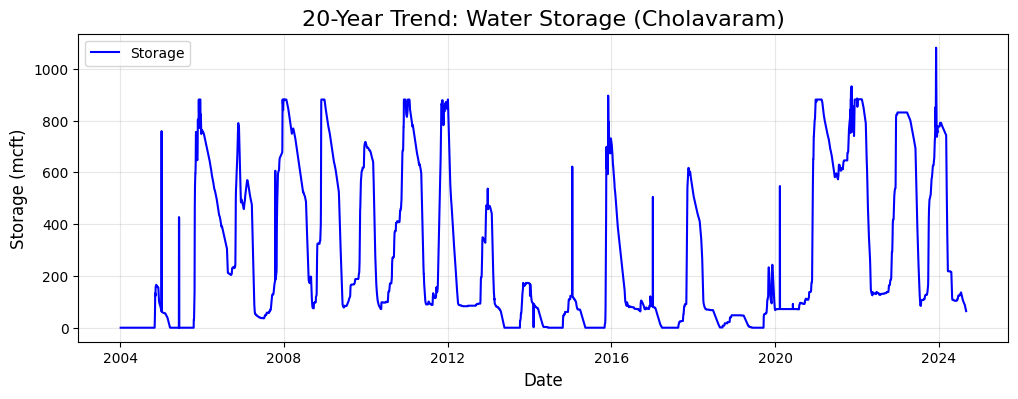

In [ ]:
plt.figure(figsize=(12, 4)) # Adjusted height for a single plot

plt.plot(df.index, df['Storage (mcft)'], color='blue', linewidth=1.5, label='Storage')

plt.title('20-Year Trend: Water Storage (Cholavaram)', fontsize=16)
plt.ylabel('Storage (mcft)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3) # Added grid for better readability

plt.show()

###**Inflow Volatility Plot**

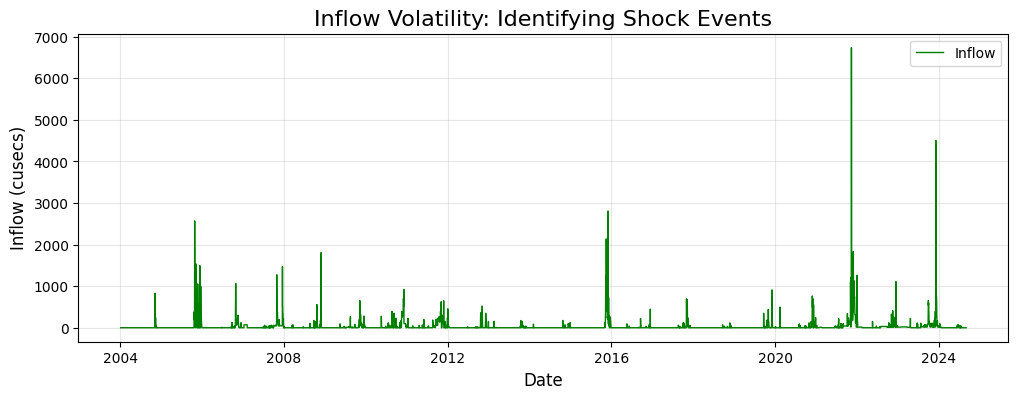

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(df.index, df['Inflow (cusecs)'], color='green', linewidth=1, label='Inflow')

plt.title('Inflow Volatility: Identifying Shock Events', fontsize=16)
plt.ylabel('Inflow (cusecs)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

###**Rainfall Pattern Plot**

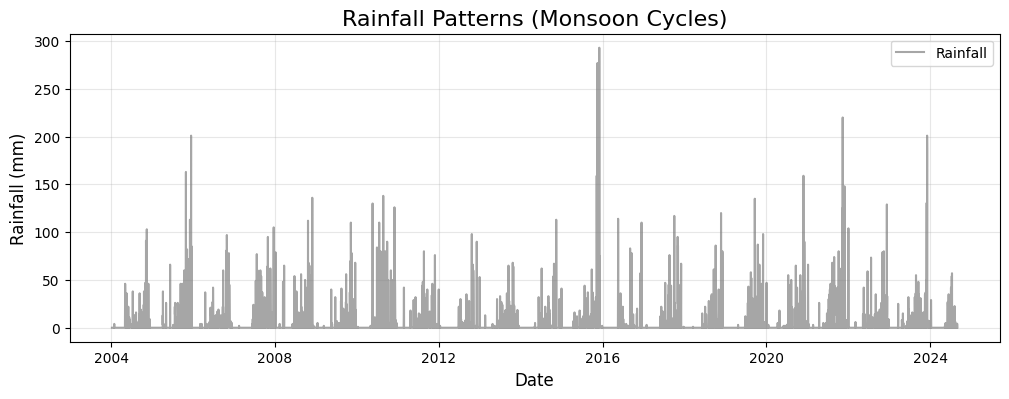

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(df.index, df['Rainfall (mm)'], color='gray', alpha=0.7, label='Rainfall')

plt.title('Rainfall Patterns (Monsoon Cycles)', fontsize=16)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

##**Seasonal Decomposition (Seasonality)**


Performing Seasonal Decomposition...


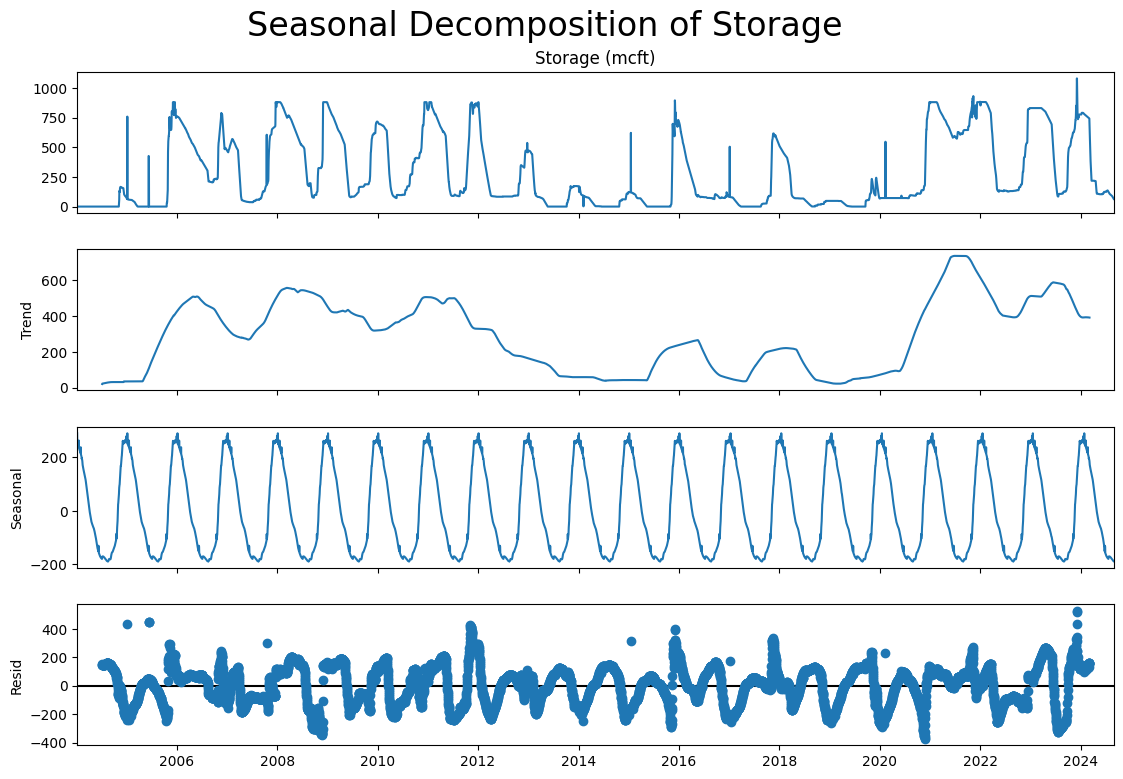

In [ ]:
print("\nPerforming Seasonal Decomposition...")
decomposition = seasonal_decompose(df['Storage (mcft)'], model='additive', period=365)

# Plotting
fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.suptitle('Seasonal Decomposition of Storage', fontsize=24, y=1.00)
plt.show()

##**Correlation Analysis (Heatmap)**


Generating Correlation Matrix...


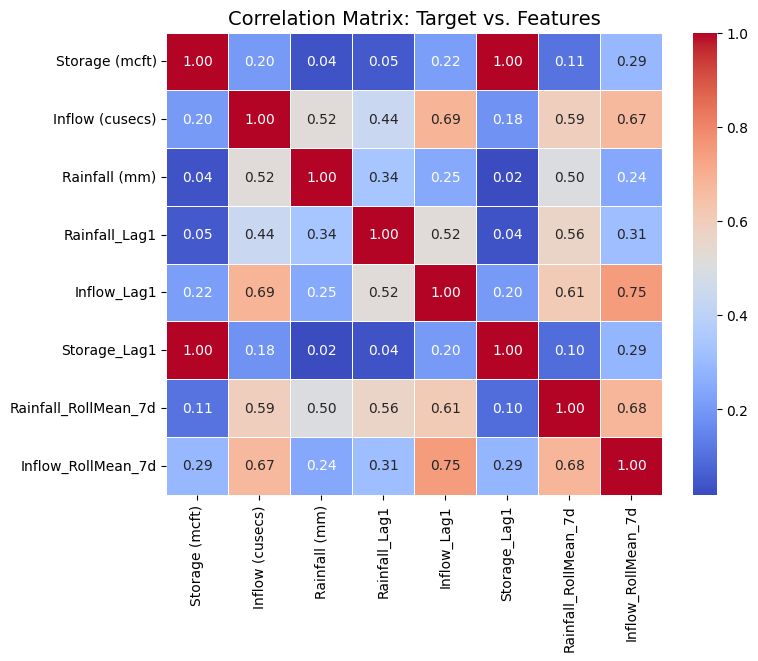

In [ ]:
print("\nGenerating Correlation Matrix...")
plt.figure(figsize=(8, 6))

cols_to_check = [
    'Storage (mcft)', 'Inflow (cusecs)', 'Rainfall (mm)',
    'Rainfall_Lag1', 'Inflow_Lag1', 'Storage_Lag1',
    'Rainfall_RollMean_7d', 'Inflow_RollMean_7d'
]

# Calculate correlation
corr_matrix = df[cols_to_check].corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Target vs. Features', fontsize=14)
plt.show()


##**Stationarity Test (ADF Test)**
**Augmented Dickey-Fuller Test (ADF Test)**

In [ ]:
print("\n--- Augmented Dickey-Fuller (ADF) Test ---")
print("Null Hypothesis: The series is Non-Stationary (Time-dependent).")
print("Alternate Hypothesis: The series is Stationary.\n")

result = adfuller(df['Storage (mcft)'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] <= 0.05:
    print("\nResult: p-value <= 0.05. The series is STATIONARY (d=0).")
else:
    print("\nResult: p-value > 0.05. The series is NON-STATIONARY (d=1 required).")


--- Augmented Dickey-Fuller (ADF) Test ---
Null Hypothesis: The series is Non-Stationary (Time-dependent).
Alternate Hypothesis: The series is Stationary.

ADF Statistic: -4.962260059276921
p-value: 2.63439190451416e-05
Critical Values:
	1%: -3.4312220889543688
	5%: -2.8619253973029872
	10%: -2.5669751425787766

Result: p-value <= 0.05. The series is STATIONARY (d=0).
